In [14]:
!pip install mlflow==3.14.0 dagshub==0.7.0 skops==0.14.0 pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 polars


# **1. Perkenalan Dataset**
**Dataset URL**: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Description**: This dataset contains historical customer data from a fictional telecommunications company in California. It includes 7,043 rows and 21 features capturing customer demographics, signed services (internet, phone, security), account settings (contract type, payment method), and charges, with the target column 'Churn' indicating whether the customer left the service within the quarter.

# **2. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


# **3. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook.

In [16]:
data_path = 'raw_data.csv'
df = pd.read_csv(data_path)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**
Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN



--- Missing Values ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- Churn Distribution ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64


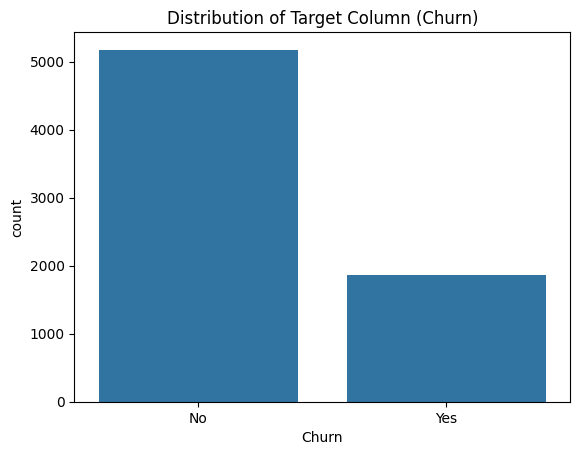

In [17]:
print("--- Data Info ---")
df.info()

print("\n--- Data Description ---")
display(df.describe(include='all'))

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Churn Distribution ---")
print(df['Churn'].value_counts())

sns.countplot(data=df, x='Churn')
plt.title('Distribution of Target Column (Churn)')
plt.show()


# **5. Data Preprocessing**
Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

In [18]:
# Drop the customerID column
df = df.drop(columns=['customerID'])

# Crucial Cleaning: Convert TotalCharges to numeric, coerce errors, and fill NaNs with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total_charges)

# Convert target column Churn to binary integers (1/0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Cleanly encode categorical features
df = pd.get_dummies(df, drop_first=True)

# Perform an 80:20 Train-Test split
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

try:
    out_dir = 'D:/dicoding/SMSML_Lukman/Membangun_model/namadataset_preprocessing'
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, 'cleaned_data.csv')
    cleaned_df = pd.concat([X, y], axis=1)
    cleaned_df.to_csv(out_path, index=False)
    print(f"Fully processed numeric-only data saved to: {out_path}")
except Exception as e:
    print(f"Could not save to local Windows path. Falling back to Colab /content/. Error: {e}")
    out_path = '/content/cleaned_data.csv'
    cleaned_df = pd.concat([X, y], axis=1)
    cleaned_df.to_csv(out_path, index=False)
    print(f"Fully processed numeric-only data saved to: {out_path}")


Fully processed numeric-only data saved to: D:/dicoding/SMSML_Lukman/Membangun_model/namadataset_preprocessing/cleaned_data.csv


# **6. Model Training & Tracking**
Pada tahap ini kita melatih model dengan MLflow dan RandomizedSearchCV.

In [19]:
# Retrieve DAGSHUB_CLIENT_TOKEN or fallback to MLFLOW_TRACKING_PASSWORD
# Masukkan token DagsHub kamu sebagai string biasa secara langsung
dagshub_token = "618385ed8cabd61fa55393eeb632a3021b166ff4"

os.environ["MLFLOW_TRACKING_USERNAME"] = "lukmannurh"
os.environ["MLFLOW_TRACKING_PASSWORD"] = dagshub_token

# Set the MLflow tracking URI headlessly
mlflow.set_tracking_uri("https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow")

# Activate autologging
mlflow.sklearn.autolog(log_models=True)

print("Starting MLflow experiment tracking session...")
with mlflow.start_run(run_name="Telco_Churn_Optimization"):

    # Initialize model
    rf = RandomForestClassifier(random_state=42)

    # Implement a controlled hyperparameter sweep
    param_dist = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=5,
        cv=3,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )

    # Train model
    search.fit(X_train, y_train)

    # Extract champion model
    champion_model = search.best_estimator_
    print("\nBest parameters found:", search.best_params_)

    # Predict on test set
    y_pred = champion_model.predict(X_test)

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\nAccuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Register the optimized champion model into the Model Registry
    mlflow.sklearn.log_model(
        sk_model=champion_model,
        artifact_path="champion_model_artifacts",
        registered_model_name="credit-scoring-model"
    )
    print("\nOptimized champion model successfully registered under 'credit-scoring-model'.")


Starting MLflow experiment tracking session...


2026/06/24 07:01:47 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/24 07:02:02 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils

🏃 View run funny-mouse-825 at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0/runs/615752f5332446928ab39ff1433cdb3a
🧪 View experiment at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0
🏃 View run serious-frog-295 at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0/runs/b7c9585c2a614450b79e6c0a8c88372d
🧪 View experiment at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0
🏃 View run capricious-skunk-420 at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0/runs/c74fd489325846ee99cadca6b80c062f
🧪 View experiment at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0
🏃 View run painted-hawk-727 at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0/runs/3a91dffa70d44733af21577d7fe0e793
🧪 View experiment at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0
🏃 View run crawling-h

2026/06/24 07:02:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Best parameters found: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None}

Accuracy:  0.8077
Precision: 0.6889
Recall:    0.4987
F1-Score:  0.5785


Registered model 'credit-scoring-model' already exists. Creating a new version of this model...
2026/06/24 07:03:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-scoring-model, version 9
Created version '9' of model 'credit-scoring-model'.



Optimized champion model successfully registered under 'credit-scoring-model'.
🏃 View run Telco_Churn_Optimization at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0/runs/d7dad385ac874ae8a44665e4ddc88ec0
🧪 View experiment at: https://dagshub.com/lukmannurh/Eksperimen_SML_Lukman.mlflow/#/experiments/0


# **7. Evaluation Metrics**


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.50      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409

--- Confusion Matrix ---
[[952  84]
 [187 186]]


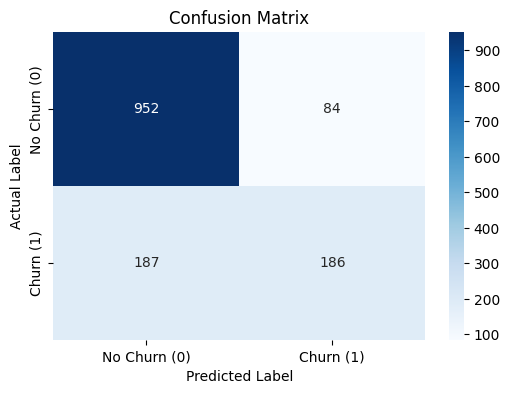

In [20]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
